# Robust Adaptive TSMOM

## An institutional-style research and engineering extension

This notebook applies public quant-development principles associated with strong electronic trading teams: exact accounting, strict timing, bounded risk, cost-aware trading, ablation tests, and visible failure modes.

It **does not** reproduce or claim access to proprietary Jane Street, Optiver, Citadel, or other firms' models. Genuine market making requires quotes, order books, queue position, order flow, latency, and fills. The supplied daily bars support a medium-frequency futures portfolio strategy instead.

## Research question

Can the literature-backed 12-month time-series momentum forecast be made more implementation-aware without hiding complexity inside an optimiser?

The adaptive model keeps the same core forecast and adds two independently testable controls:

1. **Volatility-shock taper:** reduce instrument exposure when 20-day price-change volatility rises far above its 120-day level.
2. **No-trade region:** retain the prior month-end target when a desired adjustment is smaller than 25% of the old/new position scale.

The faster 3-month trend is calculated as a diagnostic. It is disabled as a live confirmation overlay by default because the ablation result is weaker.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from delta1_cta import BacktestConfig, load_metadata, load_prices, performance_metrics, run_backtest
from institutional_strategy import (
    InstitutionalConfig,
    run_institutional_backtest,
    strategy_invariants,
    stress_test_table,
    save_institutional_outputs,
)

DATA_DIR = Path(os.environ.get(
    "DELTA1_DATA_DIR",
    str(ROOT / "data" / "Delta1"),
))
OUTPUT_DIR = ROOT / "outputs"
assert (DATA_DIR / "CATALOGUE_Delta1_Futures.csv").exists(), "Set DELTA1_DATA_DIR."
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Pipeline and timing

```text
daily CCB closes + contract catalogue
              ↓
       point-in-time forecast
              ↓
   contract dollar-risk scaling
              ↓
  lagged portfolio volatility target
              ↓
    stateful no-trade decision
              ↓
   next-business-day held position
              ↓
 contract P&L − spread − commission
```

The central timing rule is that a target formed at month-end close cannot earn that day's return. `_held_positions()` shifts it by one business row.

In [2]:
prices = load_prices(DATA_DIR)
metadata = load_metadata(DATA_DIR)

base_config = BacktestConfig(
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
    oos_start="2005-01-01",
    target_vol=0.10,
    half_spread_ticks=0.50,
    commission_per_contract=2.50,
)
strategy_config = InstitutionalConfig(
    slow_horizon=252,
    confirmation_horizon=63,
    disagreement_scale=1.00,
    shock_start=1.35,
    shock_full=2.00,
    shock_floor=0.75,
    no_trade_buffer=0.25,
)

adaptive = run_institutional_backtest(
    base_config, strategy_config, prices=prices, metadata=metadata
)
baseline = run_backtest(base_config, prices=prices, metadata=metadata)
stress = stress_test_table(base_config, prices, metadata)
checks = strategy_invariants(adaptive, base_config, strategy_config)

save_institutional_outputs(
    adaptive, baseline, stress, checks, base_config, strategy_config
)

coverage = pd.DataFrame({
    "class": metadata["asset_class"],
    "first": prices.apply(pd.Series.first_valid_index),
    "last": prices.apply(pd.Series.last_valid_index),
    "observations": prices.count(),
    "tick_size": metadata["tick_size"],
    "point_value": metadata["point_value"],
})
print(f"{prices.shape[1]} contracts | {prices.index.min().date()} to {prices.index.max().date()}")
display(coverage)

22 contracts | 1977-11-21 to 2014-12-31


,class,first,last,observations,tick_size,point_value
6A,G10 FX,1987-01-13,2014-12-31,7297,0.0001,100000
6B,G10 FX,1979-03-20,2014-12-31,9337,0.0001,62500
6C,G10 FX,1979-03-05,2014-12-31,9348,0.0001,100000
6E,G10 FX,1999-01-04,2014-12-31,4173,0.0001,125000
6J,G10 FX,1979-05-01,2014-12-31,9307,0.0001,125000
6S,G10 FX,1979-03-20,2014-12-31,9337,0.0001,125000
CL,Commodities,1983-03-30,2014-12-31,8286,0.0100,1000
ES,Equity indices,1997-09-09,2014-12-31,4517,0.2500,50
GC,Commodities,1978-03-30,2014-12-31,9590,0.1000,100
HG,Commodities,1978-04-27,2014-12-31,9570,0.0500,250


## Primary out-of-sample comparison

Both strategies use the same universe, risk target, contract accounting, and cost assumptions. The comparison isolates the shock taper and execution buffer.

,Start,End,Years,CAGR,Annualized volatility,Sharpe (rf=0),Sortino (rf=0),Max drawdown,Calmar,Positive months,Best month,Worst month,Annual cost drag,Average leverage
Robust Adaptive TSMOM,2005-01-03,2014-12-31,10.3492,0.0704,0.1056,0.6971,1.1497,-0.1861,0.3782,0.5500,0.0736,-0.0690,0.0012,0.6027
12-month TSMOM CTA,2005-01-03,2014-12-31,10.3492,0.0693,0.1069,0.6806,1.1203,-0.2019,0.3434,0.5333,0.0766,-0.0720,0.0014,0.6015


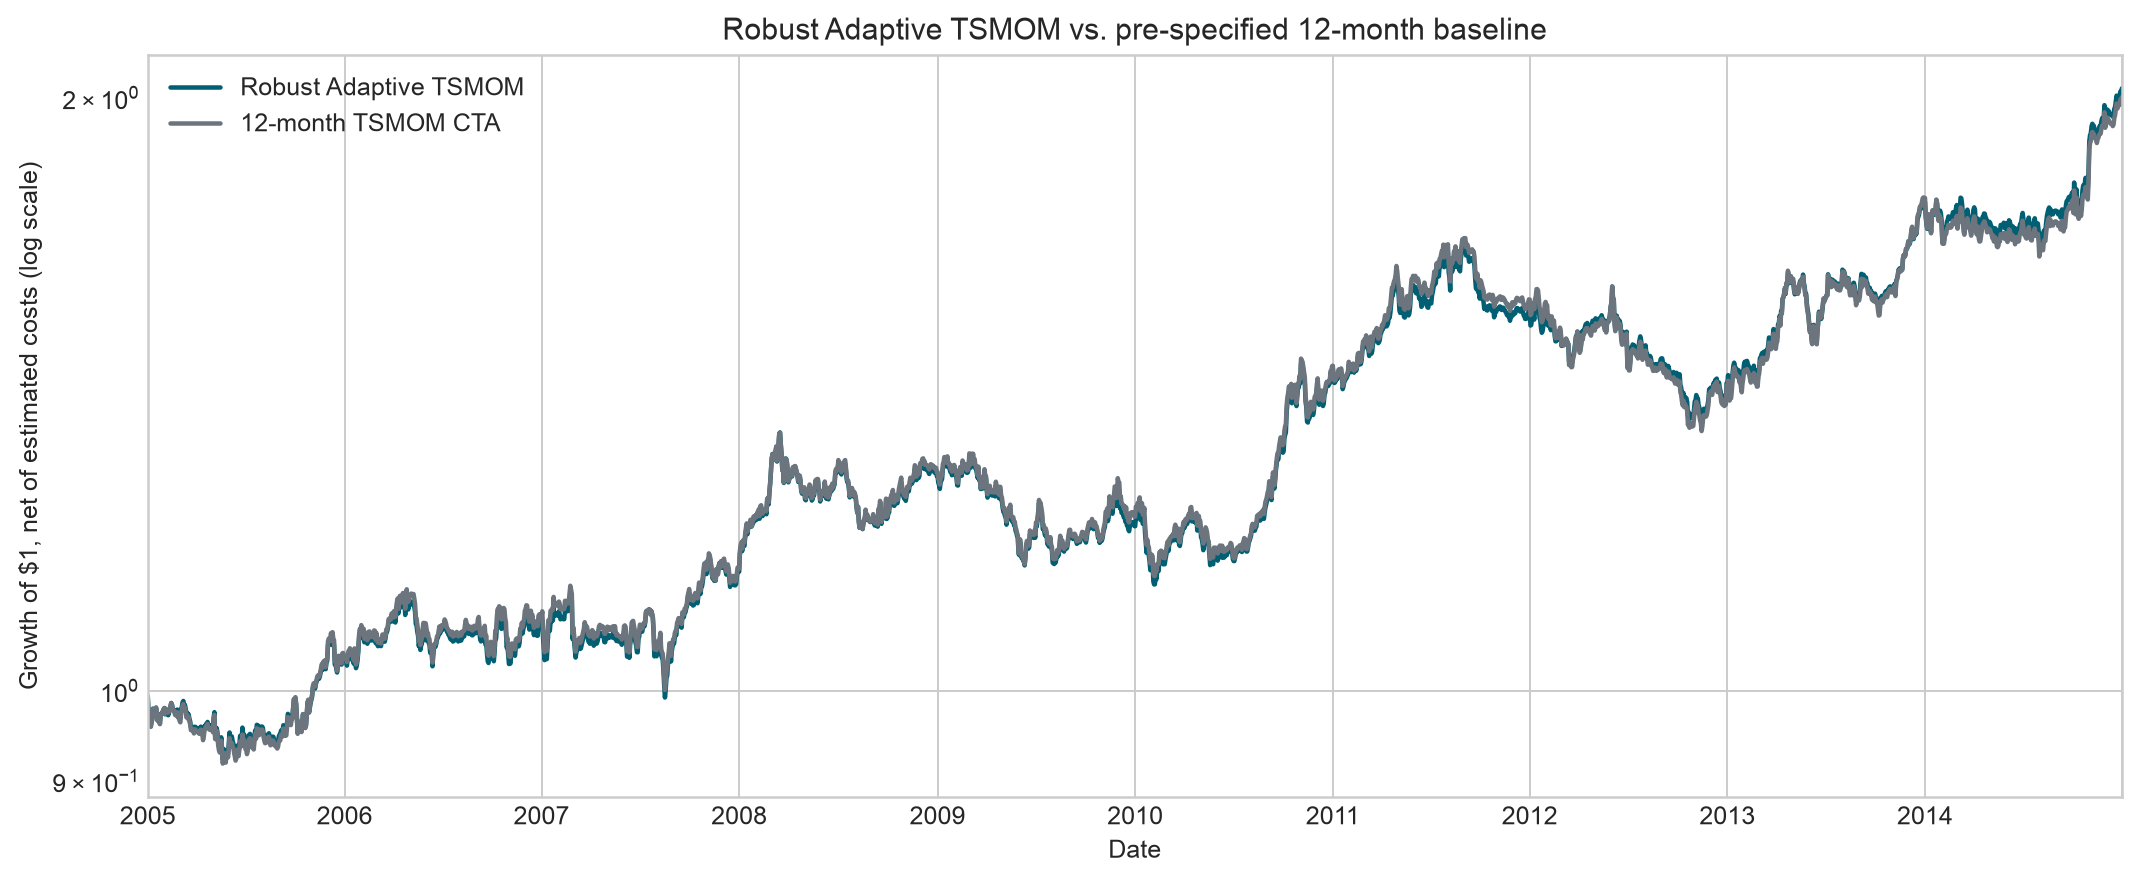

In [3]:
metrics = pd.concat([
    performance_metrics(adaptive.backtest, base_config.oos_start),
    performance_metrics(baseline, base_config.oos_start),
], axis=1).T
display(metrics)
display(Image(filename=str(OUTPUT_DIR / "institutional_performance.png")))

The improvement is modest, which is the appropriate interpretation. The no-trade region reduces estimated cost drag and changes the path of exposure; it is not a new source of economic alpha. The volatility taper slightly changes tail behavior but is not independently strong in this sample.

## Stress tests and ablations

Every variant is retained, including weak results. This prevents a polished chart from hiding which additions did not help.

In [4]:
display(stress.style.format({
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max drawdown": "{:.2%}",
    "Annual cost drag": "{:.2%}",
}))

ax = stress["Sharpe"].sort_values().plot(
    kind="barh", figsize=(10, 4.8), color="#005F73"
)
ax.set_title("OOS Sharpe across execution and model ablations")
ax.set_xlabel("Sharpe (rf=0)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

,CAGR,Volatility,Sharpe,Max drawdown,Annual cost drag
Scenario,,,,,
Base,7.04%,10.56%,0.70,-18.61%,0.12%
No trade buffer,6.93%,10.69%,0.68,-20.17%,0.14%
Wide 40% buffer,7.69%,10.76%,0.74,-19.21%,0.11%
No volatility shock control,7.09%,10.58%,0.70,-18.83%,0.12%
Aggressive 3m confirmation,6.70%,10.92%,0.65,-25.41%,0.15%
2x trading costs,6.91%,10.56%,0.69,-18.73%,0.24%
3x trading costs,6.79%,10.56%,0.67,-18.85%,0.35%


/var/folders/39/8k2n5j154v72pxxr9yybgbth0000gn/T/ipykernel_33645/4174639106.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Execution diagnostics

The next cells quantify what the controls actually do instead of describing them qualitatively.

In [5]:
desired_change = adaptive.desired_monthly_positions.diff().abs().gt(1e-15)
buffered_change = adaptive.buffered_monthly_positions.diff().abs().gt(1e-15)

diagnostics = pd.Series({
    "Desired contract-target changes": int(desired_change.sum().sum()),
    "Executed contract-target changes": int(buffered_change.sum().sum()),
    "Changes suppressed": int(desired_change.sum().sum() - buffered_change.sum().sum()),
    "OOS estimated cost drag": adaptive.backtest.daily.loc[base_config.oos_start:, "cost"].mean() * 252,
    "Mean OOS leverage": adaptive.backtest.daily.loc[base_config.oos_start:, "leverage"].mean(),
    "Share of valid instrument-days under any shock taper": (
        adaptive.shock_multiplier.loc[base_config.oos_start:].stack() < 0.999999
    ).mean(),
})
display(diagnostics)

display(checks.to_frame())
assert checks.all(), checks[~checks].to_dict()

Desired contract-target changes                        7,602.0000
Executed contract-target changes                       2,805.0000
Changes suppressed                                     4,797.0000
OOS estimated cost drag                                    0.0012
Mean OOS leverage                                          0.6027
Share of valid instrument-days under any shock taper       0.0417
dtype: float64

,Pass
finite_net_returns,True
non_negative_costs,True
forecast_in_minus_one_plus_one,True
shock_multiplier_bounded,True
positions_change_only_at_month_boundary,True
oos_exceeds_five_years,True


## Model-risk conclusion

What survives review:

- the 12-month direction remains the strongest and simplest forecast in this dataset;
- exact futures P&L and contract-specific costs are non-negotiable;
- a no-trade region is useful because it reduces churn without requiring a fragile optimiser;
- an aggressive 3-month confirmation overlay weakens results and stays disabled;
- 3x cost assumptions reduce but do not eliminate the historical edge;
- all named invariants pass.

What remains unresolved:

- the data stop in 2014;
- continuous contracts hide roll implementation;
- daily bars cannot estimate adverse selection, impact, queue position, or fill probability;
- fractional contracts omit capital and margin constraints;
- the result needs contract-level post-2014 and paper-trading validation before any deployment discussion.

The institutional lesson is not that more features are better. It is that every feature, risk rule, and execution assumption should have a separate test and an observable effect.